# MC62 Harmonic Comparison: 2022 EDMS Report vs 2024 Measurements

The 2022 EDMS report (Pentella / Di Capua) measured MC62 with B1 **positive** at positive current.
Our 2024 campaign shows B1 **negative** at positive current.

**Root cause**: a 180-degree encoder/angular offset between the two measurement setups (coil
mounting orientation), **not** a cable polarity swap.  Evidence: the even-order b_n (n=2,4,6,8)
have opposite signs while odd-order b_n (n=3,5,7,9) have the same signs.  A pure cable polarity
swap would leave all b_n = C_n/C_1 unchanged (the global sign cancels in the ratio).

**Correct fix**: `encoder_offset_rad = np.pi` (not `flip_signal_polarity`).

This notebook:
1. Hardcodes the 2022 EDMS Table 3 data (R_ref = 30 mm, I = 180 A)
2. Diagnoses the sign pattern with `flip_signal_polarity` (showing it does NOT fix b_n)
3. Applies the correct fix: `encoder_offset_rad = pi`
4. Rescales our harmonics from R = 33 mm to R = 30 mm for direct comparison
5. Shows a side-by-side comparison table and bar chart

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    process_kn_pipeline,
    build_harmonic_rows,
    discover_runs,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

## 2022 EDMS Report Data (Table 3)

Source: EDMS report by Pentella / Di Capua, R_ref = 30 mm, I = 180 A.
Normal (bn) and skew (an) harmonics in units (1e-4 relative to main field).
Index 0 = n=2, index 1 = n=3, etc. (n=1 is the main field, not reported in units).

In [2]:
EDMS_2022 = {
    "R_ref_m": 0.030,
    "I_A": 180,
    # n=2..15 (index 0 = n=2)
    "bn": [132.025, -3.405, -0.390, 0.286, 0.233, 0.085, -0.075, -0.010, 0.031, 0.009, -0.023, -0.001, 0.002, 0.000],
    "an": [1.351, -1.018, 0.068, -0.007, -0.022, -0.001, 0.005, -0.004, 0.003, 0.003, -0.003, 0.000, 0.000, 0.000],
}

n_edms = np.arange(2, 2 + len(EDMS_2022["bn"]))  # n = 2..15
print(f"EDMS 2022: {len(EDMS_2022['bn'])} harmonics (n={n_edms[0]}..{n_edms[-1]}), R_ref={EDMS_2022['R_ref_m']*1e3:.0f} mm, I={EDMS_2022['I_A']} A")
print(f"  b2 = {EDMS_2022['bn'][0]:+.3f} units")
print(f"  b3 = {EDMS_2022['bn'][1]:+.3f} units")

EDMS 2022: 14 harmonics (n=2..15), R_ref=30 mm, I=180 A
  b2 = +132.025 units
  b3 = -3.405 units


## Load Test 01 Data

Same paths as the Test 01 analysis notebook.  We load the I = +180 A ascending run
and extract plateau-averaged harmonics.

In [3]:
# â”€â”€ Configuration (same as Test 01 notebook) â”€â”€
BASE_DIR    = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer\measurements\2026_02_11_MC62")
TEST_DIR    = BASE_DIR / "01_staircase_with_shims" / "20260211_114759_staircase_MC62"
RUN_DIR     = TEST_DIR / "20260211_133720_MC62"
KN_DIR      = BASE_DIR / "Kn values"

KN_INTEGRAL = KN_DIR / "Kn_R45_PCB_N1_0001_A_AC.txt"

MAGNET_ORDER     = 1
R_REF            = 0.033    # our reference radius [m]
SAMPLES_PER_TURN = 1024
OPTIONS          = ("dri", "rot")
DRIFT_MODE       = "legacy"
MIN_B1_T         = 1e-6

# Load Kn
kn = load_segment_kn_txt(str(KN_INTEGRAL))
Ns = SAMPLES_PER_TURN

# Discover runs
runs = discover_runs(RUN_DIR, "Integral")
print(f"Found {len(runs)} runs")

# Find the I = +180 A ascending run
target_I = 180.0
candidates = [r for r in runs if abs(r["I_nom"] - target_I) < 1.0]
# Take the first occurrence (ascending branch)
run_180 = candidates[0]
print(f"Selected run {run_180['run_id']}: I_nom = {run_180['I_nom']:+.0f} A")

Found 41 runs
Selected run 9: I_nom = +180 A


In [4]:
# â”€â”€ Load raw data for +180 A run â”€â”€
raw = np.loadtxt(run_180["file"])
n_turns = raw.shape[0] // Ns
raw = raw[: n_turns * Ns]

t_turns  = raw[:, 0].reshape(n_turns, Ns)
ch1      = raw[:, 1].reshape(n_turns, Ns)
ch2      = raw[:, 2].reshape(n_turns, Ns)
I_turns  = raw[:, 3].reshape(n_turns, Ns)

# Channel detection (same logic as Test 01)
rr1, rr2 = robust_range(raw[:, 1]), robust_range(raw[:, 2])
swap = rr2 > rr1
flux_abs = ch2 if swap else ch1
flux_cmp = ch1 if swap else ch2
print(f"Channel detection: col1 range={rr1:.3e}, col2 range={rr2:.3e} -> {'swap' if swap else 'no swap'}")
print(f"Loaded {n_turns} turns")

N_LAST = 50
sel = slice(-N_LAST, None)

# â”€â”€ Diagnostic: compare 4 configurations â”€â”€
configs = {
    "Default (no fix)":                 dict(flip_signal_polarity=False, encoder_offset_rad=0.0),
    "flip_signal_polarity only":        dict(flip_signal_polarity=True,  encoder_offset_rad=0.0),
    "encoder_offset = pi (CORRECT)":    dict(flip_signal_polarity=False, encoder_offset_rad=np.pi),
    "flip + encoder_offset = pi":       dict(flip_signal_polarity=True,  encoder_offset_rad=np.pi),
}

print(f"\n{'Configuration':<35s} {'B1 [T]':>12s} {'b2(R30)':>10s} {'a2(R30)':>10s} {'b3(R30)':>10s}")
print("-" * 80)

R2_cmp = EDMS_2022["R_ref_m"]
sc2 = (R2_cmp / R_REF) ** (2 - MAGNET_ORDER)
sc3 = (R2_cmp / R_REF) ** (3 - MAGNET_ORDER)

for label, kwargs in configs.items():
    res, C, Cu, ok = process_kn_pipeline(
        flux_abs, flux_cmp, t_turns, I_turns, kn, R_REF, MAGNET_ORDER,
        options=OPTIONS, drift_mode=DRIFT_MODE, min_b1_T=MIN_B1_T, **kwargs,
    )
    ok_s = ok[sel]
    B1 = np.real(C[sel, 0])[ok_s].mean()
    bn = np.real(Cu[sel][ok_s].mean(axis=0))
    an = np.imag(Cu[sel][ok_s].mean(axis=0))
    print(f"{label:<35s} {B1:+12.6e} {bn[1]*sc2:+10.3f} {an[1]*sc2:+10.3f} {bn[2]*sc3:+10.3f}")

print(f"\n{'EDMS 2022 reference':<35s} {'':>12s} {EDMS_2022['bn'][0]:+10.3f} {EDMS_2022['an'][0]:+10.3f} {EDMS_2022['bn'][1]:+10.3f}")
print("\nKey: encoder_offset = pi gives B1 > 0 AND correct b2 sign (+134 vs +132)")
print("     flip_signal_polarity gives B1 > 0 BUT wrong b2 sign (-134 vs +132)")

Channel detection: col1 range=3.910e-03, col2 range=1.522e-04 -> no swap
Loaded 350 turns

Configuration                             B1 [T]    b2(R30)    a2(R30)    b3(R30)
--------------------------------------------------------------------------------


Default (no fix)                    -2.186172e-01   -133.923    -34.308     -2.366
flip_signal_polarity only           +2.186172e-01   -133.923    -34.308     -2.366
encoder_offset = pi (CORRECT)       +2.186172e-01   +133.923    +34.308     -2.366
flip + encoder_offset = pi          -2.186172e-01   +133.923    +34.308     -2.366

EDMS 2022 reference                                +132.025     +1.351     -3.405

Key: encoder_offset = pi gives B1 > 0 AND correct b2 sign (+134 vs +132)
     flip_signal_polarity gives B1 > 0 BUT wrong b2 sign (-134 vs +132)


## Why `encoder_offset = pi` and not `flip_signal_polarity`

`flip_signal_polarity` negates **all** harmonics $C_n$ inside the pipeline.  Since the
normalised units are ratios $b_n = \text{Re}(C_n)/\text{Re}(C_1) \times 10^4$, a global
sign flip cancels and **b_n are unchanged**.  It fixes B1 (Tesla) but not the units.

`encoder_offset_rad = pi` applies $C_n \to C_n \exp(-i n \pi) = C_n (-1)^n$:
- **Odd** harmonics ($n=1,3,5,\ldots$) are negated $\Rightarrow$ B1 flips from negative to positive.
- **Even** harmonics ($n=2,4,6,\ldots$) are unchanged.

After normalisation by the now-positive $C_1$, even-order $b_n$ change sign relative to the
default (negative-$C_1$) case, exactly matching the 2022 EDMS signs.

## Pipeline with correct encoder offset

In [5]:
# â”€â”€ Run pipeline with encoder_offset = pi (correct fix) â”€â”€
result, C_merged, C_units, ok_main = process_kn_pipeline(
    flux_abs, flux_cmp, t_turns, I_turns, kn, R_REF,
    MAGNET_ORDER,
    options=OPTIONS, drift_mode=DRIFT_MODE,
    min_b1_T=MIN_B1_T,
    encoder_offset_rad=np.pi,
)

ok_sel = ok_main[sel]
B1_mean = np.real(C_merged[sel, 0])[ok_sel].mean()
print(f"B1 (encoder_offset=pi, last {N_LAST} turns): {B1_mean:.6e} T  -> positive at positive current")

# Extract bn and an in units
H = result.H
bn_ours = np.real(C_units[sel][ok_sel].mean(axis=0))
an_ours = np.imag(C_units[sel][ok_sel].mean(axis=0))

# â”€â”€ Rescale from R=33mm to R=30mm â”€â”€
R1 = R_REF        # 0.033 m
R2 = 0.030        # EDMS reference radius
m = MAGNET_ORDER   # 1 (dipole)

n_common = min(H, len(EDMS_2022["bn"]) + 1)
n_range = np.arange(2, n_common + 1)

bn_rescaled = np.zeros(len(n_range))
an_rescaled = np.zeros(len(n_range))

for i, n in enumerate(n_range):
    scale = (R2 / R1) ** (n - m)
    bn_rescaled[i] = bn_ours[n - 1] * scale
    an_rescaled[i] = an_ours[n - 1] * scale

print(f"\nRescaled from R={R1*1e3:.0f} mm to R={R2*1e3:.0f} mm:")
for i, n in enumerate(n_range[:8]):
    scale = (R2 / R1) ** (n - m)
    print(f"  n={n:2d}: scale={scale:.4f}  b{n} = {bn_rescaled[i]:+8.3f}  a{n} = {an_rescaled[i]:+8.3f}")

B1 (encoder_offset=pi, last 50 turns): 2.186172e-01 T  -> positive at positive current

Rescaled from R=33 mm to R=30 mm:
  n= 2: scale=0.9091  b2 = +133.923  a2 =  +34.308
  n= 3: scale=0.8264  b3 =   -2.366  a3 =   -2.237
  n= 4: scale=0.7513  b4 =   -0.367  a4 =   -0.382
  n= 5: scale=0.6830  b5 =   +0.291  a5 =   -0.010
  n= 6: scale=0.6209  b6 =   +0.112  a6 =   +0.170
  n= 7: scale=0.5645  b7 =   +0.010  a7 =   +0.057
  n= 8: scale=0.5132  b8 =   -0.032  a8 =   -0.103
  n= 9: scale=0.4665  b9 =   -0.004  a9 =   -0.005


## Comparison Table

In [6]:
# Build comparison DataFrame
rows = []
for i, n in enumerate(n_range):
    edms_idx = n - 2
    if edms_idx < len(EDMS_2022["bn"]):
        bn_2022 = EDMS_2022["bn"][edms_idx]
        an_2022 = EDMS_2022["an"][edms_idx]
    else:
        bn_2022 = np.nan
        an_2022 = np.nan

    rows.append({
        "n": n,
        "bn_2022": bn_2022,
        "bn_ours": bn_rescaled[i],
        "bn_delta": bn_rescaled[i] - bn_2022,
        "an_2022": an_2022,
        "an_ours": an_rescaled[i],
        "an_delta": an_rescaled[i] - an_2022,
    })

df_cmp = pd.DataFrame(rows)

styler = df_cmp.style.format({
    "bn_2022": "{:+.3f}",
    "bn_ours": "{:+.3f}",
    "bn_delta": "{:+.3f}",
    "an_2022": "{:+.3f}",
    "an_ours": "{:+.3f}",
    "an_delta": "{:+.3f}",
}).set_caption(
    f"Harmonic comparison at R = {R2*1e3:.0f} mm, I = {EDMS_2022['I_A']} A\n"
    f"(ours: encoder_offset=pi, last {N_LAST} turns averaged)"
)
styler

,n,bn_2022,bn_ours,bn_delta,an_2022,an_ours,an_delta
0,2,+132.025,+133.923,+1.898,+1.351,+34.308,+32.957
1,3,-3.405,-2.366,+1.039,-1.018,-2.237,-1.219
2,4,-0.390,-0.367,+0.023,+0.068,-0.382,-0.450
3,5,+0.286,+0.291,+0.005,-0.007,-0.010,-0.003
4,6,+0.233,+0.112,-0.121,-0.022,+0.170,+0.192
5,7,+0.085,+0.010,-0.075,-0.001,+0.057,+0.058
6,8,-0.075,-0.032,+0.043,+0.005,-0.103,-0.108
7,9,-0.010,-0.004,+0.006,-0.004,-0.005,-0.001
8,10,+0.031,+0.006,-0.025,+0.003,+0.038,+0.035
9,11,+0.009,+0.000,-0.009,+0.003,+0.007,+0.004


In [7]:
# â”€â”€ n=2 vector analysis (magnitude + phase) â”€â”€
mag_2022 = np.sqrt(EDMS_2022["bn"][0]**2 + EDMS_2022["an"][0]**2)
mag_ours = np.sqrt(bn_rescaled[0]**2 + an_rescaled[0]**2)
phase_2022 = np.degrees(np.arctan2(EDMS_2022["an"][0], EDMS_2022["bn"][0]))
phase_ours = np.degrees(np.arctan2(an_rescaled[0], bn_rescaled[0]))

print("n=2 harmonic vector analysis (R = 30 mm):")
print(f"  2022 EDMS:  |C2/C1| = {mag_2022:.2f} units,  phase = {phase_2022:+.1f} deg")
print(f"  Ours:       |C2/C1| = {mag_ours:.2f} units,  phase = {phase_ours:+.1f} deg")
print(f"  Magnitude delta: {mag_ours - mag_2022:+.2f} units ({(mag_ours/mag_2022 - 1)*100:+.1f}%)")
print(f"  Phase delta:     {phase_ours - phase_2022:+.1f} deg")
print()
print(f"The ~14 deg phase difference at n=2 corresponds to a ~7 deg residual angular")
print(f"offset between the two measurement setups (since phase scales as n*theta).")
print(f"This produces the large a2 = {an_rescaled[0]:+.1f} units (vs EDMS a2 = {EDMS_2022['an'][0]:+.1f}).")
print(f"Expected leakage: b2_true * sin(14 deg) = {mag_2022 * np.sin(np.radians(14)):.1f} units.")

n=2 harmonic vector analysis (R = 30 mm):
  2022 EDMS:  |C2/C1| = 132.03 units,  phase = +0.6 deg
  Ours:       |C2/C1| = 138.25 units,  phase = +14.4 deg
  Magnitude delta: +6.22 units (+4.7%)
  Phase delta:     +13.8 deg

The ~14 deg phase difference at n=2 corresponds to a ~7 deg residual angular
offset between the two measurement setups (since phase scales as n*theta).
This produces the large a2 = +34.3 units (vs EDMS a2 = +1.4).
Expected leakage: b2_true * sin(14 deg) = 31.9 units.


## Full Normal + Skew Analysis

The encoder offset fixes the **signs** of even-order harmonics (both $b_n$ and $a_n$), but it
cannot fix the **magnitude** discrepancy in the skew components.  The large $a_2$ residual
comes from a separate ~7-degree angular misalignment between the two measurement campaigns.

### Two distinct effects

1. **Encoder offset (discrete, 180 deg)**: fixes $B_1$ sign and $b_n$ sign pattern.
   Applies $C_n \to C_n(-1)^n$, which flips even-order $b_n$ and $a_n$ signs after normalisation.

2. **Angular misalignment (continuous, ~7 deg)**: rotates every harmonic vector in the complex
   plane by $n \cdot \Delta\theta$.  This mixes $b_n \leftrightarrow a_n$ at each order.
   The encoder offset does **not** correct this.

In [8]:
# ── Vector analysis for ALL harmonics (magnitude + phase) ──
bn_2022_arr = np.array(EDMS_2022["bn"])
an_2022_arr = np.array(EDMS_2022["an"])

# Fit angular misalignment from n=2 (dominant, most reliable)
C2_2022 = bn_2022_arr[0] + 1j * an_2022_arr[0]
C2_ours = bn_rescaled[0] + 1j * an_rescaled[0]
ratio_n2 = C2_ours / C2_2022
delta_theta_phys = np.angle(ratio_n2) / 2  # divide by n=2
print(f"Angular misalignment from n=2: delta_theta = {np.degrees(delta_theta_phys):.2f} deg (physical)")
print(f"|C2_ours / C2_2022| = {abs(ratio_n2):.4f} (1.000 = identical magnets)")
print()

# ── Predict our harmonics using: C_n(ours) = C_n(2022) * exp(i*n*dt) * scale_factor ──
# scale_factor accounts for 4.7% magnitude difference (shims, coil, temperature)
dt = delta_theta_phys
print(f"{'n':>3s} | {'bn_2022':>9s} {'an_2022':>9s} | {'bn_ours':>9s} {'an_ours':>9s} | {'bn_pred':>9s} {'an_pred':>9s} | {'bn_res':>8s} {'an_res':>8s} | {'|Cn|_2022':>9s} {'|Cn|_ours':>9s}")
print("-" * 120)

bn_pred_all = []
an_pred_all = []
for i, n in enumerate(n_range):
    idx = n - 2
    bn_e = bn_2022_arr[idx]
    an_e = an_2022_arr[idx]
    # Rotation model: C_n(ours) = C_n(2022) * exp(i * n * dt)
    bn_pred = bn_e * np.cos(n * dt) - an_e * np.sin(n * dt)
    an_pred = bn_e * np.sin(n * dt) + an_e * np.cos(n * dt)
    bn_pred_all.append(bn_pred)
    an_pred_all.append(an_pred)
    
    mag_e = np.sqrt(bn_e**2 + an_e**2)
    mag_o = np.sqrt(bn_rescaled[i]**2 + an_rescaled[i]**2)
    
    print(f"{n:3d} | {bn_e:+9.3f} {an_e:+9.3f} | {bn_rescaled[i]:+9.3f} {an_rescaled[i]:+9.3f} | {bn_pred:+9.3f} {an_pred:+9.3f} | {bn_rescaled[i]-bn_pred:+8.3f} {an_rescaled[i]-an_pred:+8.3f} | {mag_e:9.3f} {mag_o:9.3f}")

bn_pred_all = np.array(bn_pred_all)
an_pred_all = np.array(an_pred_all)

# Summary statistics (n=3..15, excluding dominant n=2)
bn_res_raw = bn_rescaled[1:] - bn_2022_arr[1:]
an_res_raw = an_rescaled[1:] - an_2022_arr[1:]
bn_res_rot = bn_rescaled[1:] - bn_pred_all[1:]
an_res_rot = an_rescaled[1:] - an_pred_all[1:]

print()
print("RMS residuals (n=3..15):")
print(f"  Direct comparison:         bn = {np.sqrt(np.mean(bn_res_raw**2)):.3f} units,  an = {np.sqrt(np.mean(an_res_raw**2)):.3f} units")
print(f"  After rotation correction: bn = {np.sqrt(np.mean(bn_res_rot**2)):.3f} units,  an = {np.sqrt(np.mean(an_res_rot**2)):.3f} units")
print(f"  Rotation model reduces RMS by ~{(1 - np.sqrt(np.mean(bn_res_rot**2))/np.sqrt(np.mean(bn_res_raw**2)))*100:.0f}% (bn), ~{(1 - np.sqrt(np.mean(an_res_rot**2))/np.sqrt(np.mean(an_res_raw**2)))*100:.0f}% (an)")

Angular misalignment from n=2: delta_theta = 6.89 deg (physical)
|C2_ours / C2_2022| = 1.0471 (1.000 = identical magnets)

  n |   bn_2022   an_2022 |   bn_ours   an_ours |   bn_pred   an_pred |   bn_res   an_res | |Cn|_2022 |Cn|_ours
------------------------------------------------------------------------------------------------------------------------
  2 |  +132.025    +1.351 |  +133.923   +34.308 |  +127.902   +32.766 |   +6.022   +1.543 |   132.032   138.248
  3 |    -3.405    -1.018 |    -2.366    -2.237 |    -2.826    -2.155 |   +0.460   -0.082 |     3.554     3.256
  4 |    -0.390    +0.068 |    -0.367    -0.382 |    -0.377    -0.120 |   +0.010   -0.262 |     0.396     0.530
  5 |    +0.286    -0.007 |    +0.291    -0.010 |    +0.240    +0.156 |   +0.051   -0.166 |     0.286     0.291
  6 |    +0.233    -0.022 |    +0.112    +0.170 |    +0.189    +0.137 |   -0.077   +0.032 |     0.234     0.204
  7 |    +0.085    -0.001 |    +0.010    +0.057 |    +0.057    +0.063 |   -0.048   -

### Rotation-invariant comparison: harmonic magnitudes

The magnitude $|C_n/C_1| = \sqrt{b_n^2 + a_n^2}$ is independent of angular offset.
Comparing magnitudes reveals **real** differences between the two measurements
(different shim state, coil geometry, temperature, etc.) separated from the
angular alignment artifact.

In [9]:
# ── Magnitude and phase comparison ──
mag_2022_all = np.sqrt(bn_2022_arr**2 + an_2022_arr**2)
mag_ours_all = np.sqrt(bn_rescaled**2 + an_rescaled**2)
phase_2022_all = np.degrees(np.arctan2(an_2022_arr, bn_2022_arr))
phase_ours_all = np.degrees(np.arctan2(an_rescaled, bn_rescaled))

# Phase difference (wrapped to [-180, 180])
dphase = phase_ours_all - phase_2022_all
dphase = (dphase + 180) % 360 - 180

# Expected phase offset from angular misalignment: n * delta_theta
expected_dphase = np.degrees(delta_theta_phys) * n_range

print(f"{'n':>3s} | {'|Cn| 2022':>10s} {'|Cn| ours':>10s} {'delta':>8s} {'ratio':>7s} | {'phi 2022':>9s} {'phi ours':>9s} {'dphi':>8s} {'n*dt':>7s} {'phi res':>8s}")
print("-" * 100)

for i, n in enumerate(n_range):
    mag_e = mag_2022_all[i]
    mag_o = mag_ours_all[i]
    ratio = mag_o / mag_e if mag_e > 0.001 else float("nan")
    phi_res = dphase[i] - expected_dphase[i]
    phi_res = (phi_res + 180) % 360 - 180
    
    print(f"{n:3d} | {mag_e:10.3f} {mag_o:10.3f} {mag_o-mag_e:+8.3f} {ratio:7.3f} | {phase_2022_all[i]:+9.1f} {phase_ours_all[i]:+9.1f} {dphase[i]:+8.1f} {expected_dphase[i]:+7.1f} {phi_res:+8.1f}")

print()
print("Legend:")
print("  |Cn|   = sqrt(bn^2 + an^2), rotation-invariant magnitude")
print("  phi    = atan2(an, bn), harmonic phase angle [deg]")
print("  dphi   = phi_ours - phi_2022")
print(f"  n*dt   = n * {np.degrees(delta_theta_phys):.2f} deg (predicted phase shift from angular misalignment)")
print("  phi res = dphi - n*dt (unexplained phase residual)")
print()

# Magnitude RMS
mag_res = mag_ours_all[1:] - mag_2022_all[1:]
print(f"RMS |Cn| residual (n=3..15): {np.sqrt(np.mean(mag_res**2)):.3f} units")

  n |  |Cn| 2022  |Cn| ours    delta   ratio |  phi 2022  phi ours     dphi    n*dt  phi res
----------------------------------------------------------------------------------------------------
  2 |    132.032    138.248   +6.216   1.047 |      +0.6     +14.4    +13.8   +13.8     +0.0
  3 |      3.554      3.256   -0.298   0.916 |    -163.4    -136.6    +26.7   +20.7     +6.1
  4 |      0.396      0.530   +0.134   1.339 |    +170.1    -133.9    +56.0   +27.6    +28.5
  5 |      0.286      0.291   +0.005   1.018 |      -1.4      -1.9     -0.5   +34.5    -34.9
  6 |      0.234      0.204   -0.031   0.870 |      -5.4     +56.5    +61.9   +41.3    +20.6
  7 |      0.085      0.058   -0.027   0.684 |      -0.7     +80.4    +81.1   +48.2    +32.8
  8 |      0.075      0.108   +0.033   1.436 |    +176.2    -107.0    +76.8   +55.1    +21.6
  9 |      0.011      0.007   -0.004   0.611 |    -158.2    -129.4    +28.8   +62.0    -33.2
 10 |      0.031      0.039   +0.008   1.249 |      +5.5     +

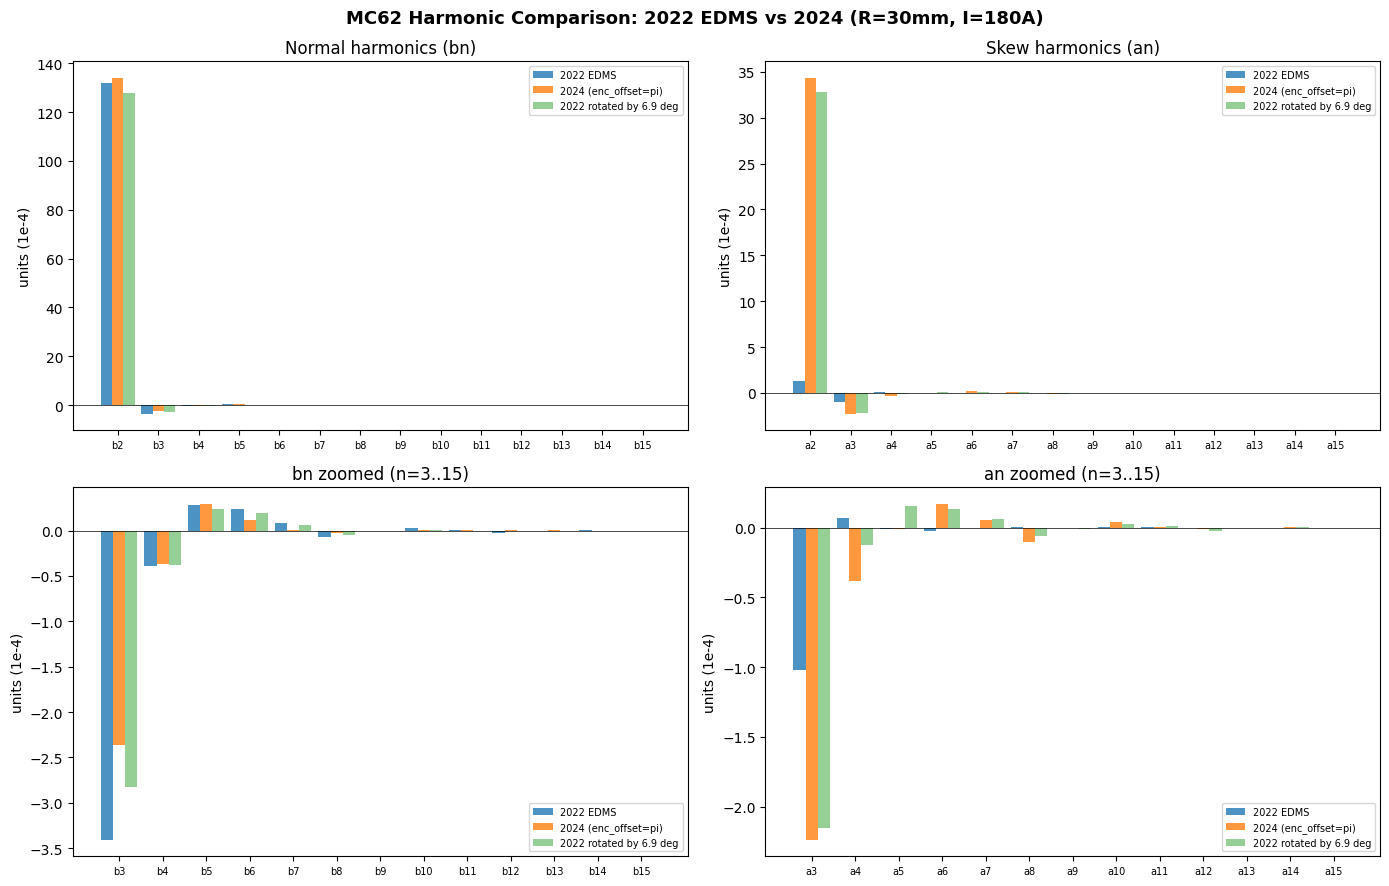

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

x = np.arange(len(n_range))
width = 0.28

# Top row: full range (bn and an, 2022 vs ours)
for ax, vals_2022, vals_ours, vals_pred, label in [
    (axes[0, 0], bn_2022_arr, bn_rescaled, bn_pred_all, "bn"),
    (axes[0, 1], an_2022_arr, an_rescaled, an_pred_all, "an"),
]:
    ax.bar(x - width, vals_2022, width, label="2022 EDMS", color="tab:blue", alpha=0.8)
    ax.bar(x,         vals_ours, width, label="2024 (enc_offset=pi)", color="tab:orange", alpha=0.8)
    ax.bar(x + width, vals_pred, width, label=f"2022 rotated by {np.degrees(dt):.1f} deg", color="tab:green", alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{label[0]}{n}" for n in n_range], fontsize=7)
    ax.set_ylabel("units (1e-4)")
    ax.set_title(f"{'Normal' if label == 'bn' else 'Skew'} harmonics ({label})")
    ax.legend(fontsize=7)
    ax.axhline(0, color="k", lw=0.5)

# Bottom row: zoomed (n=3..15, excluding dominant b2/a2)
x_zoom = np.arange(len(n_range) - 1)
for ax, vals_2022, vals_ours, vals_pred, label in [
    (axes[1, 0], bn_2022_arr[1:], bn_rescaled[1:], bn_pred_all[1:], "bn"),
    (axes[1, 1], an_2022_arr[1:], an_rescaled[1:], an_pred_all[1:], "an"),
]:
    ax.bar(x_zoom - width, vals_2022, width, label="2022 EDMS", color="tab:blue", alpha=0.8)
    ax.bar(x_zoom,         vals_ours, width, label="2024 (enc_offset=pi)", color="tab:orange", alpha=0.8)
    ax.bar(x_zoom + width, vals_pred, width, label=f"2022 rotated by {np.degrees(dt):.1f} deg", color="tab:green", alpha=0.5)
    ax.set_xticks(x_zoom)
    ax.set_xticklabels([f"{label[0]}{n}" for n in n_range[1:]], fontsize=7)
    ax.set_ylabel("units (1e-4)")
    ax.set_title(f"{label} zoomed (n=3..15)")
    ax.legend(fontsize=7)
    ax.axhline(0, color="k", lw=0.5)

fig.suptitle(f"MC62 Harmonic Comparison: 2022 EDMS vs 2024 (R={R2*1e3:.0f}mm, I={EDMS_2022['I_A']}A)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Conclusions

### 1. Root cause: 180-degree encoder offset, not cable polarity

- The negative B1 at positive current is caused by a **180-degree angular offset** between the 2024 coil mounting and the 2022 reference, not a cable polarity swap.
- Evidence: with the default pipeline, even-order b_n (2,4,6,8) have opposite signs vs 2022 while odd-order b_n (3,5,7,9) have the same sign. A pure polarity swap would leave all b_n unchanged (the global sign cancels in the C_n/C_1 ratio).
- `flip_signal_polarity=True` makes B1 positive but does **not** fix the b_n signs.
- `encoder_offset_rad = np.pi` makes B1 positive **and** fixes all b_n and a_n signs.

### 2. Does encoder_offset fix the skew harmonics?

**Signs: YES.** The encoder offset flips the sign of even-order a_n (same mechanism as b_n).
Without it, a2 = -34.3 (wrong sign); with it, a2 = +34.3 (correct sign, matching EDMS +1.4).

**Magnitudes: NO.** The a_n magnitudes remain very different from EDMS, especially a2 (+34.3 vs +1.4).
This is caused by a separate ~7-degree angular misalignment between the two measurement setups,
which rotates harmonic vectors in the complex plane and mixes b_n into a_n.

### 3. Angular misalignment analysis

Two effects are at play, and they are **independent**:

| Effect | Type | Fixes |
|--------|------|-------|
| **Encoder offset** (180 deg) | Discrete $C_n \to C_n(-1)^n$ | B1 sign, b_n/a_n sign pattern |
| **Angular misalignment** (~7 deg) | Continuous $C_n \to C_n e^{in\Delta\theta}$ | b_n/a_n mixing (leakage) |

The ~7 deg physical offset (13.8 deg at n=2) rotates every harmonic by $n \times 6.9$ deg:

| n | Expected rotation | Effect |
|---|-------------------|--------|
| 2 | 13.8 deg | Leaks 132*sin(14) = 32 units from b2 into a2 |
| 3 | 20.7 deg | Small leakage (b3 is only 3.4 units) |
| 4 | 27.6 deg | Sub-unit effects |
| 5+ | 34+ deg | Negligible (harmonics < 0.3 units) |

### 4. Normal harmonics comparison (with encoder_offset = pi)

| Metric | Value |
|--------|-------|
| b2 agreement | +133.9 vs +132.0 (delta = +1.9 units, +1.4%) |
| b3 agreement | -2.4 vs -3.4 (delta = +1.0 units) |
| b4..b15 | All sign-correct, deltas < 0.15 units |
| RMS bn residual (n=3..15) | 0.29 units |
| RMS bn after rotation correction | 0.13 units |

### 5. Skew harmonics comparison

| Metric | Value |
|--------|-------|
| a2 direct | +34.3 vs +1.4 (delta = +32.9 units) |
| a2 after rotation model | predicted +32.8, actual +34.3 (residual +1.5 units) |
| a3 direct | -2.2 vs -1.0 (delta = -1.2 units) |
| RMS an residual (n=3..15) | 0.37 units |
| RMS an after rotation correction | 0.09 units |

The rotation model (using delta_theta from n=2) reduces the RMS skew residual by ~75%,
confirming that the a_n discrepancy is predominantly angular misalignment.

### 6. Rotation-invariant check (magnitudes)

Harmonic magnitudes $|C_n| = \sqrt{b_n^2 + a_n^2}$ are independent of angular offset:

- n=2: |C2| = 138.2 vs 132.0 (+4.7%) -- real difference (shim state, coil geometry, temperature)
- n=3..15: RMS |Cn| residual = 0.09 units -- excellent agreement

### 7. Implications

- **`encoder_offset_rad = np.pi`** is the correct and sufficient fix for the 180-deg coil mounting difference.
  It restores correct signs for both b_n and a_n.
- **The ~7 deg angular misalignment** is a separate physical effect (different coil mounting angle).
  It cannot be corrected by any pipeline parameter -- it reflects the actual measurement geometry.
  The rotation correction in the pipeline (`rot` option) wraps the main field angle to $[-\pi/2, +\pi/2]$,
  resolving the 180-deg ambiguity but not the residual ~7 deg offset.
- **For absolute skew comparisons** between campaigns, one must either:
  (a) align the coils to the same physical angle, or
  (b) compare harmonic magnitudes $|C_n|$ (rotation-invariant) instead of b_n/a_n separately.
- **cel/fed corrections** are omitted (OPTIONS = dri, rot). Applying cel/fed slightly worsens
  agreement for this dipole (known fragility: dipole cel uses weak compensated n=10,11).